###**Proyecto 2 Unidad 4**

**Segmentación de Estudiantes en Redes Sociales con
K-Means**

Profesor:

*Dr. José Gabriel Rodríguez Rivas*

Alumnos:

*Alejandro Fernández*

*Carolina Alvarado*



**Objetivo del Proyecto**

El objetivo de este proyecto es aplicar el algoritmo K-Means para realizar una segmentación
de estudiantes basada en su perfil de red social, utilizando datos demográficos, de intereses,
estilo de vida y actividades. El propósito es identificar grupos de estudiantes con
comportamientos similares, tales como jóvenes deportistas, usuarios fiesteros,
estudiantes religiosos, o socializadores introvertidos, para que los alumnos comprendan
cómo el clustering puede usarse en análisis de usuarios y marketing social.

**Objetivos Específicos**

1. **Explorar variables del dataset** para familiarizarse con el contenido de las variables .
2. **Describir las variables** para comprender su significado y papel dentro del análisis.
3. **Aplicar PCA** para reducir la dimensionalidad y analizar la contribución de cada
componente.
4. **Implementar K-Means** para descubrir agrupamientos naturales dentro de los
pacientes.
5. **Visualizar los resultados del clustering**, tanto en el espacio original (cuando sea
posible) como en el espacio reducido por PCA.
6. **Interpretar los clusters** en términos de riesgo o características clínicas relevantes.

**2. Contexto**

En la era digital, la actividad en redes sociales refleja no solo conexiones sociales sino
también intereses, valores y hábitos de vida. Las universidades, los departamentos de
bienestar estudiantil y los desarrolladores de redes sociales pueden beneficiarse de conocer
estos perfiles para diseñar programas, campañas o servicios más efectivos.
El dataset **Students’ Social Network Profile** (disponible en Kaggle) proporciona datos
ficticios o reales sobre estudiantes, incluyendo su edad, género, número de amigos, intereses
de deporte, música, estilo de vida y religión. Al segmentar estos perfiles con **K-Means**, los
estudiantes (tus alumnos) podrán aprender a detectar patrones de comportamiento y diseñar
estrategias basadas en ellos.


**3. Variables del Dataset**

| Variable | Significado |
|----------|-------------|
| **age** | Edad del estudiante. |
| **gender** | Género del estudiante (por ejemplo, masculino/femenino). |
| **gradyear** | Año de graduación del estudiante (por ejemplo, 2023, 2024). |
| **NumberOfFriends** | Cantidad de amigos que tiene en la red social. |
| **basketball, football, soccer, etc.** | Variables binarias (0/1) sobre si al estudiante le interesa o practica cada deporte. |
| **music, rock, pop, etc.** | Intereses musicales, representados como variables (pueden ser binarias o de frecuencia). |
| **shopping, drugs, death, etc.** | Comportamientos o menciones de estilo de vida: por ejemplo, si el estudiante habla de "shopping", "drugs" o "death" en su perfil. |
| **god, church, jesus** | Variables relacionadas con la religión, que miden la afinidad o la frecuencia de referencias religiosas en el perfil. |

**3.1. Agregar dataset**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

file_id = "1Ld3jWC6nIcPWsJtbpy2exoqm-nVoozUt"
url = f"https://drive.google.com/uc?id={file_id}"
student = pd.read_csv(url)
print(student.head(10))

Mounted at /content/drive
   gradyear gender     age  NumberOffriends  basketball  football  soccer  \
0      2007    NaN     NaN                0           0         0       0   
1      2007      F   17.41               49           0         0       1   
2      2007      F  17.511               41           0         0       0   
3      2006      F     NaN               36           0         0       0   
4      2008      F  16.657                1           0         0       0   
5      2008      M  18.034               32           0         5       0   
6      2006      M   18.53               18           0         0       0   
7      2006      F     NaN                0           0         0       0   
8      2006      F  19.168                0           0         0       0   
9      2007    NaN     NaN               21           0         0       0   

   softball  volleyball  swimming  ...  blonde  mall  shopping  clothes  \
0         0           0         0  ...       0     

**3.2. Limpieza de datos**

In [ ]:
student['gender'] = student['gender'].str.strip()
student['gender'] = student['gender'].map({'F': 0, 'M': 1})
print(student['gender'].value_counts(dropna=False))

gender
0.0    11057
1.0     2606
NaN     1337
Name: count, dtype: int64


In [ ]:
student = student.fillna(student.median(numeric_only=True))
print("Nulos restantes:", student.isnull().sum().sum())

Nulos restantes: 2496


In [ ]:
print(student.dtypes[student.dtypes == 'object'])
print()
print(student.isnull().sum()[student.isnull().sum() > 0])

age    object
dtype: object

age    2496
dtype: int64


In [ ]:
student['age'] = pd.to_numeric(student['age'], errors='coerce')

print(student['age'].dtype)
print(student['age'].describe())

float64
count    12228.000000
mean        17.988164
std          7.715857
min          4.309000
25%         16.331000
50%         17.295000
75%         18.264000
max        106.927000
Name: age, dtype: float64


In [ ]:
student.loc[student['age'] < 10, 'age'] = np.nan
student.loc[student['age'] > 30, 'age'] = np.nan

student = student.fillna(student.median(numeric_only=True))

print("Nulos restantes:", student.isnull().sum().sum())  # Debe dar 0
print(student['age'].describe())

Nulos restantes: 0
count    15000.000000
mean        17.283733
std          1.090461
min         11.559000
25%         16.548000
50%         17.281000
75%         18.012000
max         29.796000
Name: age, dtype: float64


**3.3. Estandarización de los datos**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(student)

X_scaled_df = pd.DataFrame(X_scaled, columns=student.columns)
print(X_scaled_df.describe().round(2))

       gradyear    gender       age  NumberOffriends  basketball  football  \
count  15000.00  15000.00  15000.00         15000.00    15000.00  15000.00   
mean      -0.00      0.00     -0.00             0.00        0.00     -0.00   
std        1.00      1.00      1.00             1.00        1.00      1.00   
min       -1.34     -0.46     -5.25            -0.84       -0.34     -0.36   
25%       -1.34     -0.46     -0.67            -0.76       -0.34     -0.36   
50%        0.45     -0.46     -0.00            -0.28       -0.34     -0.36   
75%        0.45     -0.46      0.67             0.40       -0.34     -0.36   
max        1.35      2.18     11.47            16.25       27.55     12.45   

         soccer  softball  volleyball  swimming  ...    blonde      mall  \
count  15000.00  15000.00    15000.00  15000.00  ...  15000.00  15000.00   
mean      -0.00     -0.00       -0.00     -0.00  ...     -0.00     -0.00   
std        1.00      1.00        1.00      1.00  ...      1.00      1

**3.4. Análisis de Componentes Principales (PCA)**

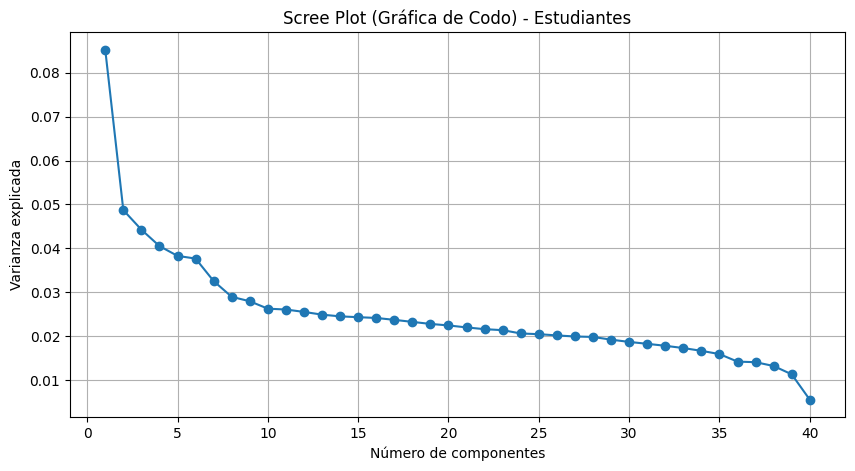

Varianza por componente: [0.08527255 0.04872367 0.04426584 0.04052743 0.03828779 0.03767501
 0.03255013 0.02895738 0.02794691 0.02625798 0.02606392 0.02552047
 0.0248959  0.02450588 0.02432127 0.02414454 0.0237125  0.0232461
 0.02278355 0.02243739 0.02198707 0.02158726 0.0213596  0.02060849
 0.02044694 0.02016181 0.01991943 0.01981915 0.01919626 0.01868264
 0.01824897 0.0177995  0.01728274 0.01664966 0.01590942 0.01418989
 0.01406369 0.01319044 0.01129246 0.00550835]
Varianza acumulada: [0.08527255 0.13399622 0.17826206 0.2187895  0.25707729 0.2947523
 0.32730243 0.35625981 0.38420672 0.41046471 0.43652863 0.4620491
 0.486945   0.51145088 0.53577215 0.5599167  0.5836292  0.60687529
 0.62965884 0.65209623 0.6740833  0.69567056 0.71703017 0.73763866
 0.7580856  0.77824741 0.79816684 0.81798599 0.83718225 0.85586488
 0.87411385 0.89191335 0.90919609 0.92584575 0.94175517 0.95594507
 0.97000876 0.9831992  0.99449165 1.        ]


In [ ]:
# PCA completo para ver todas las varianzas
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker='o'
)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot (Gráfica de Codo) - Estudiantes")
plt.grid(True)
plt.show()

print("Varianza por componente:", pca_full.explained_variance_ratio_)
print("Varianza acumulada:", pca_full.explained_variance_ratio_.cumsum())

**Determinación del número de componentes**

Se evaluaron los 40 componentes posibles mediante el Scree Plot.
Se eligieron **27 componentes** porque explican el **79.82% de la varianza acumulada**,
superando el umbral recomendado del 75-80%. A partir del componente 27, la ganancia
marginal de varianza es menor al 2% por componente, lo que indica que los componentes
restantes aportan principalmente ruido.

In [ ]:
# Elegimos n componentes que expliquen al menos el 75-80% acumulado
pca = PCA(n_components=27)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print("Varianza por componente:", explained_variance.round(4))
print("Varianza acumulada:", np.cumsum(explained_variance).round(4))

Varianza por componente: [0.0853 0.0487 0.0443 0.0405 0.0383 0.0377 0.0326 0.029  0.0279 0.0263
 0.0261 0.0255 0.0249 0.0245 0.0243 0.0241 0.0237 0.0232 0.0228 0.0224
 0.022  0.0216 0.0214 0.0206 0.0204 0.0202 0.0199]
Varianza acumulada: [0.0853 0.134  0.1783 0.2188 0.2571 0.2948 0.3273 0.3563 0.3842 0.4105
 0.4365 0.462  0.4869 0.5115 0.5358 0.5599 0.5836 0.6069 0.6297 0.6521
 0.6741 0.6957 0.717  0.7376 0.7581 0.7782 0.7982]


In [ ]:
componentes = pd.DataFrame(
    pca.components_,
    columns=student.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)
print("Contribución de variables a cada componente:")
print(componentes.round(3))

Contribución de variables a cada componente:
      gradyear  gender    age  NumberOffriends  basketball  football  soccer  \
PC1      0.099  -0.094 -0.091            0.087       0.143     0.133   0.076   
PC2      0.500  -0.175 -0.497            0.121       0.079     0.012   0.063   
PC3      0.213   0.030 -0.205            0.099       0.045     0.021   0.032   
PC4      0.270   0.298 -0.260           -0.039       0.182     0.214   0.089   
PC5     -0.241   0.236  0.272            0.043       0.327     0.361   0.141   
PC6     -0.195  -0.117  0.197            0.125       0.006     0.046   0.012   
PC7      0.068   0.274 -0.058           -0.124      -0.120    -0.028  -0.047   
PC8     -0.014  -0.243  0.010           -0.009       0.128    -0.177   0.051   
PC9     -0.029  -0.004  0.041            0.257       0.066     0.133  -0.068   
PC10    -0.044  -0.084  0.039           -0.141       0.048    -0.200   0.047   
PC11     0.006   0.024 -0.007           -0.015      -0.125     0.014   0.40

In [ ]:
# Top 5 variables más influyentes por componente
print("=== Variables más influyentes por componente ===\n")
for i in range(5):  # Solo PC1 a PC5 para no saturar
    pc = componentes.iloc[i]
    top = pc.abs().sort_values(ascending=False).head(5)
    print(f"PC{i+1} ({pca.explained_variance_ratio_[i]*100:.2f}%):")
    for var, val in zip(top.index, pc[top.index]):
        print(f"  {var:20s}: {val:.3f}")
    print()

=== Variables más influyentes por componente ===

PC1 (8.53%):
  hair                : 0.352
  kissed              : 0.268
  clothes             : 0.242
  music               : 0.240
  cute                : 0.212

PC2 (4.87%):
  gradyear            : 0.500
  age                 : -0.497
  god                 : -0.210
  bible               : -0.185
  jesus               : -0.180

PC3 (4.43%):
  jesus               : 0.529
  god                 : 0.485
  bible               : 0.473
  church              : 0.254
  gradyear            : 0.213

PC4 (4.05%):
  band                : 0.350
  marching            : 0.321
  gender              : 0.298
  gradyear            : 0.270
  age                 : -0.260

PC5 (3.83%):
  football            : 0.361
  baseball            : 0.348
  basketball          : 0.327
  sports              : 0.317
  marching            : -0.281



**Interpretación**

**PC1 (8.53%) — Perfil social / atractivo físico**

hair, kissed, clothes, music, cute → Estudiantes enfocados en apariencia, socialización y cultura pop.

**PC2 (4.87%) — Dimensión temporal / generacional**

gradyear (+) y age (-) dominan, con god, bible, jesus negativos → Estudiantes mayores tienden a tener menos referencias religiosas en su perfil.

**PC3 (4.43%) — Perfil religioso**

jesus, god, bible, church dominan claramente → Este componente captura perfectamente el perfil de estudiantes religiosos que mencionaba el proyecto.

**PC4 (4.05%) — Banda / música escolar + demográfico**

band, marching dominan → Estudiantes de banda escolar, con componente de género y edad.

**PC5 (3.83%) — Perfil deportista**

football, baseball, basketball, sports muy claros → El cluster de deportistas que predice el proyecto.


**3.5. Aplicación de K-Means**

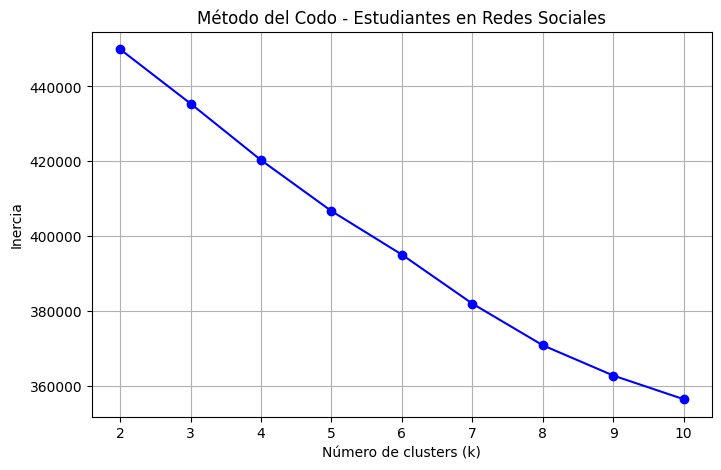

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertias, 'bo-')
plt.title("Método del Codo - Estudiantes en Redes Sociales")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

resultados = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)
    inercia = km.inertia_
    silhouette = silhouette_score(X_pca, labels)
    resultados.append({"k": k, "inercia": round(inercia, 2), "silhouette": round(silhouette, 4)})

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

 k   inercia  silhouette
 2 449955.02      0.3716
 3 435421.20      0.3705
 4 420302.33      0.2350
 5 406679.20      0.0569
 6 395023.41      0.0539
 7 381920.44      0.0581
 8 370779.66      0.0556
 9 362692.10      0.0573
10 356356.39      0.0595


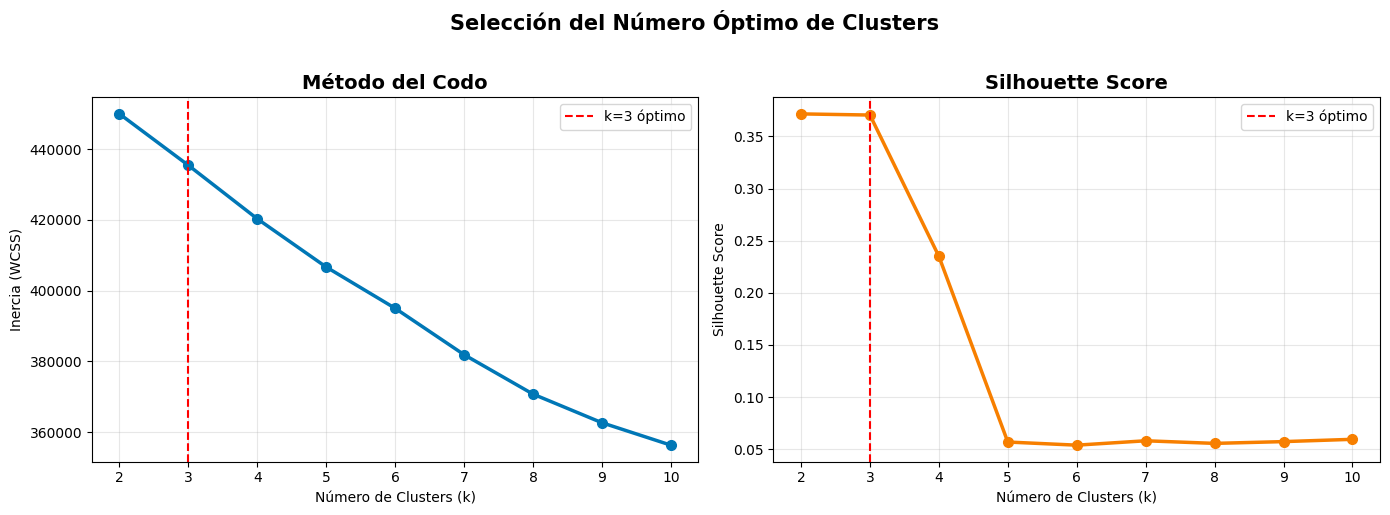

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]
inertia   = [449955.02, 435421.20, 420302.33, 406679.20, 395023.41, 381920.44, 370779.66, 362692.10, 356356.39]
silhouette = [0.3716, 0.3705, 0.2350, 0.0569, 0.0539, 0.0581, 0.0556, 0.0573, 0.0595]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Método del Codo ---
ax1.plot(k_values, inertia, marker='o', color='#0077B6', linewidth=2.5, markersize=7)
ax1.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='k=3 óptimo')
ax1.set_title('Método del Codo', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_xticks(k_values)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Silhouette Score ---
ax2.plot(k_values, silhouette, marker='o', color='#F77F00', linewidth=2.5, markersize=7)
ax2.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='k=3 óptimo')
ax2.set_title('Silhouette Score', fontsize=14, fontweight='bold')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_values)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Selección del Número Óptimo de Clusters', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**¿Por qué elegimos k=3?**

Al analizar la tabla de resultados, lo primero que llama la atención es que el Silhouette
Score cae drásticamente después de k=3. Con k=2 y k=3 los valores son casi iguales
(0.3716 y 0.3705), pero a partir de k=4 el score baja a 0.2350 y de k=5 en adelante
se desploma a valores cercanos a 0.05, lo que indica que los clusters prácticamente
se mezclan entre sí.

Entonces, ¿por qué k=3 y no k=2? Porque con solo 2 grupos la segmentación es demasiado
general y poco útil. Con k=3 obtenemos un grupo adicional que nos permite distinguir
mejor los perfiles de estudiantes, como por ejemplo separar a los estudiantes religiosos
de los deportistas, o identificar un grupo más social. La pérdida en silhouette es
mínima (0.001) y la ganancia en interpretación es significativa.

Por eso elegimos k=3 como el número óptimo de clusters para este análisis.

In [ ]:
k_optimo = 3

kmeans = KMeans(n_clusters=k_optimo, random_state=42)
clusters = kmeans.fit_predict(X_pca)

print(f"K-Means entrenado con k = {k_optimo}")
print(f"Inercia: {kmeans.inertia_:.2f}")

K-Means entrenado con k = 3
Inercia: 435421.20


In [ ]:
student["cluster"] = clusters

print("Distribución de estudiantes por cluster:")
print(student["cluster"].value_counts().sort_index())

Distribución de estudiantes por cluster:
cluster
0     2411
1    12588
2        1
Name: count, dtype: int64


In [ ]:
# Ver quién es el estudiante del cluster 2
print(student[student["cluster"] == 2])

      gradyear  gender     age  NumberOffriends  basketball  football  soccer  \
2006      2007     0.0  18.119               44           0         2       0   

      softball  volleyball  swimming  ...  mall  shopping  clothes  hollister  \
2006         0           0         1  ...     0         0        1          0   

      abercrombie  die  death  drunk  drugs  cluster  
2006            0    6      6      6      0        2  

[1 rows x 41 columns]


In [ ]:
# Eliminar el outlier y reentrenar
student = student[student["cluster"] != 2].copy()
student = student.drop(columns=["cluster"])

# Reescalar
X_scaled = scaler.fit_transform(student)

# Re-aplicar PCA
X_pca = pca.fit_transform(X_scaled)

# Reentrenar K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)
student["cluster"] = clusters

print("Distribución de estudiantes por cluster:")
print(student["cluster"].value_counts().sort_index())

Distribución de estudiantes por cluster:
cluster
0    1295
1    6795
2    6909
Name: count, dtype: int64


**3.6. Visualización**

 Gráfico PC1 vs PC2

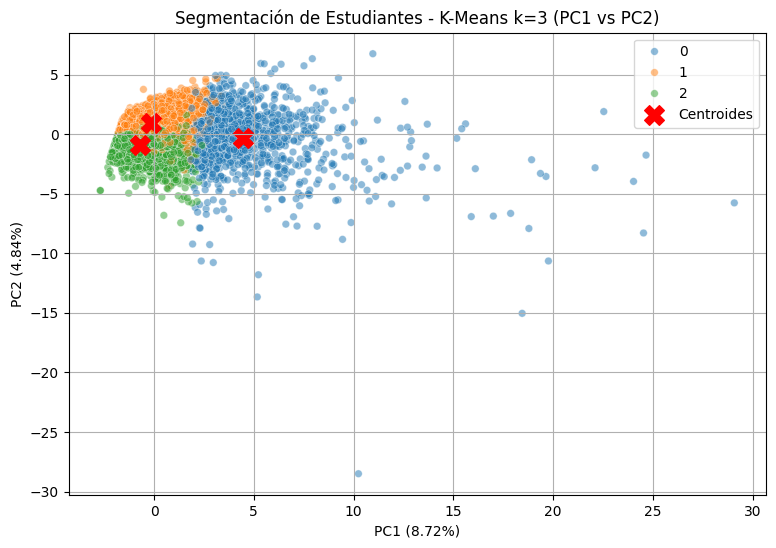

In [ ]:
import seaborn as sns

# Resetear índice
student = student.reset_index(drop=True)

# Agregar componentes PCA al dataset
student["pca1"] = X_pca[:, 0]
student["pca2"] = X_pca[:, 1]

# Centroides ya están en espacio PCA
centroids_pca = kmeans.cluster_centers_

plt.figure(figsize=(9, 6))
sns.scatterplot(data=student, x="pca1", y="pca2",
                hue="cluster", palette="tab10", alpha=0.5, s=30)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Estudiantes - K-Means k=3 (PC1 vs PC2)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.legend()
plt.grid(True)
plt.show()

Gráfico PC3 vs PC4

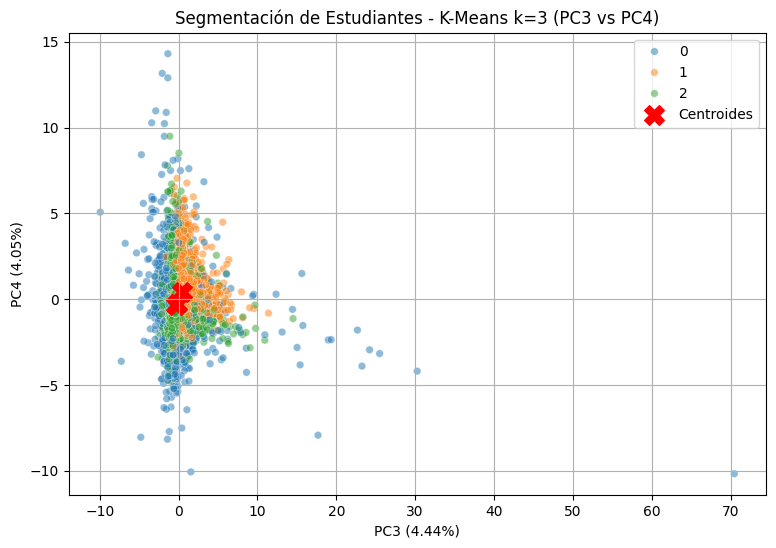

In [ ]:
student["pca3"] = X_pca[:, 2]
student["pca4"] = X_pca[:, 3]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=student, x="pca3", y="pca4", hue="cluster", palette="tab10", alpha=0.5, s=30)
plt.scatter(centroids_pca[:,2], centroids_pca[:,3], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Estudiantes - K-Means k=3 (PC3 vs PC4)")
plt.xlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)")
plt.ylabel(f"PC4 ({pca.explained_variance_ratio_[3]*100:.2f}%)")
plt.legend()
plt.grid(True)
plt.show()

Biplot PC1 vs PC2

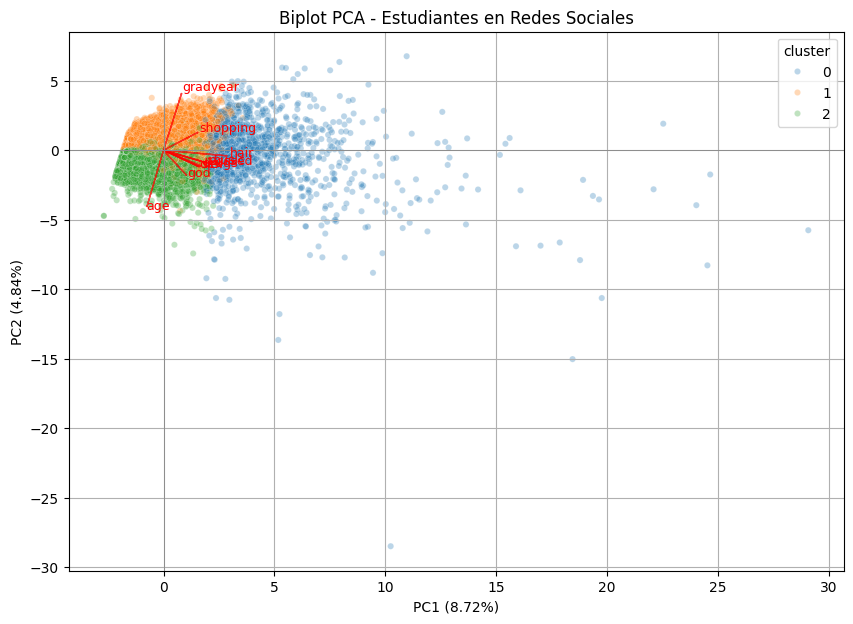

In [ ]:
# Usamos las variables originales para el biplot
features = student.drop(columns=["cluster","pca1","pca2","pca3","pca4"]).columns
loadings = pca.components_.T

plt.figure(figsize=(10, 7))
sns.scatterplot(data=student, x="pca1", y="pca2", hue="cluster", palette="tab10", alpha=0.3, s=20)

# Flechas solo de las 10 variables más influyentes en PC1 y PC2
importancia = np.sqrt(loadings[:,0]**2 + loadings[:,1]**2)
top_idx = np.argsort(importancia)[-10:]

for i in top_idx:
    plt.arrow(0, 0,
              loadings[i, 0] * 8,
              loadings[i, 1] * 8,
              color='red', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 8.5,
             loadings[i, 1] * 8.5,
             features[i], color='red', fontsize=9)

plt.title("Biplot PCA - Estudiantes en Redes Sociales")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.grid(True)
plt.show()

**3.7. Interpretación de resultados**

In [ ]:
# Columnas originales sin las de PCA y cluster
features_originales = student.drop(columns=["cluster", "pca1", "pca2"]).columns

resumen = student.groupby("cluster")[features_originales].mean().round(2)
print(resumen.T)  # Transpuesto para leerlo mejor

cluster                0        1        2
gradyear         2007.73  2008.45  2006.51
gender              0.08     0.15     0.21
age                17.09    16.49    18.10
NumberOffriends    38.15    32.24    25.91
basketball          0.68     0.29     0.17
football            0.60     0.25     0.20
soccer              0.43     0.25     0.16
softball            0.29     0.20     0.10
volleyball          0.31     0.18     0.07
swimming            0.35     0.14     0.09
cheerleading        0.30     0.11     0.06
baseball            0.24     0.10     0.08
tennis              0.16     0.08     0.09
sports              0.43     0.13     0.10
cute                1.11     0.27     0.24
sex                 1.30     0.10     0.12
sexy                0.42     0.13     0.10
hot                 0.33     0.14     0.07
kissed              0.78     0.04     0.04
dance               1.13     0.43     0.30
band                0.81     0.24     0.26
marching            0.10     0.03     0.04
music      

**Cluster 0 — "Estudiantes Fiesteros y Socialmente Activos" (1,295 estudiantes)**

Este grupo tiene los valores más altos en casi todas las variables del dataset.
Destacan en deportes (basketball=0.68, football=0.60), pero lo que realmente
los define es su vida social intensa: altos valores en sex, cute, kissed, hair,
shopping, mall y también en drugs, drunk y die. Tienen el mayor número de amigos
(38.15) y son los más activos en su perfil de red social.

**Perfil:** Son el equivalente a los "estudiantes fiesteros" del proyecto. No solo
hablan de fiestas sino de apariencia, compras, música y deporte al mismo tiempo.
Su perfil es el más completo y expresivo de los tres.

**Desde el punto de vista de bienestar estudiantil:** Este grupo requiere atención
porque combina alta vida social con menciones de drugs y drunk. Una intervención
preventiva enfocada en hábitos saludables sería pertinente para este segmento.

**Desde el punto de vista de marketing:** Son el público ideal para marcas de ropa
(hollister, abercrombie), música y eventos deportivos. Responden bien a contenido
visual y tendencias sociales.

---

**Cluster 1 — "Estudiantes Jóvenes con Intereses Variados" (6,795 estudiantes)**

Son el grupo más joven (16.49 años) con valores moderados en todo: algo de deporte,
algo de música, algo de religión (god=0.39, church=0.23) y un número de amigos
moderado (32.24). No tienen una identidad muy marcada en su perfil pero están
presentes en múltiples temas.

**Perfil:** Son el grupo más "promedio" del dataset. Están en una etapa de exploración
donde todavía no tienen una identidad social definida. Un poco deportistas, un poco
religiosos, un poco sociales.

**Desde el punto de vista de bienestar estudiantil:** Al ser el grupo más grande y
más joven, son el segmento con mayor potencial de influencia. Programas de orientación
vocacional o actividades extracurriculares podrían ayudarles a definir sus intereses.

**Desde el punto de vista de marketing:** Son receptivos a contenido variado. Campañas
generales de universidades o plataformas educativas tendrían buena llegada en este grupo.

---

**Cluster 2 — "Estudiantes Mayores e Introvertidos" (6,909 estudiantes)**

Son los de mayor edad (18.10 años) y los valores más bajos en casi todo: pocos amigos
(25.91), poca actividad deportiva, baja mención de temas sociales o de apariencia.
Son principalmente estudiantes de años de graduación más antiguos (2006), lo que
sugiere que están en sus últimos años de carrera.

**Perfil:** Son el equivalente a los "estudiantes introvertidos" del proyecto. Su perfil
de red social es reservado y poco expresivo. No necesariamente son inactivos en la vida
real, simplemente comparten menos en redes sociales.

**Desde el punto de vista de bienestar estudiantil:** Al ser estudiantes mayores con
poca red social visible, podrían ser un grupo en riesgo de aislamiento. Programas de
integración o mentoría entre pares serían útiles para este segmento.

**Desde el punto de vista de marketing:** Son más difíciles de alcanzar por redes
sociales. Canales más directos como email, foros académicos o plataformas de empleo
serían más efectivos para este grupo.

**Interpretación de Perfiles e Intervenciones Posibles**

**Cluster 0 — "Estudiantes Fiesteros y Socialmente Activos"**

*¿Quiénes son?*

El grupo más expresivo en redes. Hablan de apariencia, compras, deporte y
música, pero también de alcohol y drogas. Tienen muchos amigos y una
identidad social muy marcada.

*En términos sociales:*

Son líderes de opinión naturales dentro de la comunidad estudiantil, pero
la combinación de vida social intensa con conductas de riesgo los hace
vulnerables.

*Intervenciones posibles:*

- Campañas de prevención de adicciones en redes sociales con lenguaje
  juvenil y sin ser alarmistas.
- Involucrarlos como embajadores en actividades deportivas o culturales
  para canalizar su energía hacia espacios positivos.
- Responden bien a contenido visual, retos virales y campañas con
  influencers estudiantiles.

---

**Cluster 1 — "Estudiantes Jóvenes en Exploración"**

*¿Quiénes son?*

El grupo más numeroso y más joven. Intereses variados pero ninguno muy
marcado. Están en una etapa donde todavía definen su identidad.

*En términos sociales:*

Representan el mayor potencial de impacto para intervenciones universitarias
por ser el grupo más grande y más receptivo a nuevas experiencias.

*Intervenciones posibles:*

- Ferias de actividades extracurriculares donde exploren deportes, arte,
  música y voluntariado.
- Programas de orientación y mentorías con estudiantes mayores.
- Campañas de integración universitaria y promoción de eventos variados
  en redes sociales.

---

**Cluster 2 — "Estudiantes Mayores e Introvertidos"**

*¿Quiénes son?*

Estudiantes de mayor edad y menor actividad en redes. Pocos amigos y poca
mención de vida social. Probablemente en sus últimos años de carrera.

*En términos sociales:*

Son difíciles de alcanzar por canales digitales y existe riesgo de
aislamiento social, especialmente en la transición hacia la vida profesional.

*Intervenciones posibles:*

- Programas de bienestar enfocados en salud mental y manejo del estrés
  académico.
- Espacios presenciales como grupos de tesis o clubes académicos.
- Contenido útil en redes: becas, empleos, networking profesional.

**3.8. Conclusiones**

**Conclusiones**

A través de este proyecto se logró aplicar exitosamente el algoritmo K-Means
para segmentar a 14,999 estudiantes en 3 grupos con características claramente
diferenciadas. El uso de PCA fue clave para reducir las 40 variables originales
a 27 componentes que explican el 79.82% de la varianza, permitiendo que el
algoritmo trabajara de manera más eficiente y los resultados fueran más
interpretables.

Los tres clusters identificados reflejan perfiles estudiantiles reales y
coherentes: un grupo socialmente activo con conductas de riesgo, un grupo
joven en exploración de identidad y un grupo mayor más reservado. Esto
confirma que los datos de redes sociales sí contienen patrones de comportamiento
detectables mediante técnicas de clustering no supervisado.

**Recomendaciones**

Desde el punto de vista académico, se recomienda explorar otros valores de k
o algoritmos alternativos como DBSCAN que manejan mejor los outliers, ya que
durante el análisis se identificó un estudiante atípico que tuvo que ser
eliminado para obtener clusters balanceados.

Desde el punto de vista institucional, los perfiles obtenidos pueden ser una
herramienta útil para que las universidades diseñen estrategias de comunicación,
programas de bienestar y campañas de prevención adaptadas a cada tipo de
estudiante, en lugar de aplicar intervenciones genéricas para toda la población.

Finalmente, es importante recordar que este análisis se basa en lo que los
estudiantes publican en redes sociales, no necesariamente en quiénes son en
la realidad. Los perfiles deben interpretarse como una aproximación y no como
una caracterización definitiva de los estudiantes.